<a href="https://colab.research.google.com/github/rajatofficial33/LightCNN/blob/main/LightCNNModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Our proposed Lightweight CNN Model with Residual Attention Network & Attention Mechanism**

Device: cuda, Params: 336,272
Epoch 1/20 | Train loss 1.8022, acc 0.3108 | Val loss 1.7205, acc 0.3563
Epoch 2/20 | Train loss 1.5565, acc 0.4012 | Val loss 2.2344, acc 0.3113
Epoch 3/20 | Train loss 1.4511, acc 0.4440 | Val loss 1.5197, acc 0.3962
Epoch 4/20 | Train loss 1.3276, acc 0.5014 | Val loss 1.5114, acc 0.4587
Epoch 5/20 | Train loss 1.2420, acc 0.5346 | Val loss 1.4158, acc 0.4662
Epoch 6/20 | Train loss 1.1886, acc 0.5554 | Val loss 1.6357, acc 0.4150
Epoch 7/20 | Train loss 1.1162, acc 0.5878 | Val loss 1.2622, acc 0.5250
Epoch 8/20 | Train loss 1.0741, acc 0.6002 | Val loss 1.2615, acc 0.5275
Epoch 9/20 | Train loss 1.0270, acc 0.6236 | Val loss 1.1954, acc 0.5587
Epoch 10/20 | Train loss 0.9909, acc 0.6410 | Val loss 1.7704, acc 0.4125
Epoch 11/20 | Train loss 0.9691, acc 0.6452 | Val loss 1.1696, acc 0.5550
Epoch 12/20 | Train loss 0.9401, acc 0.6554 | Val loss 1.2788, acc 0.5587
Epoch 13/20 | Train loss 0.8852, acc 0.6798 | Val loss 1.0763, acc 0.5975
Epoch 14/20 | Tra

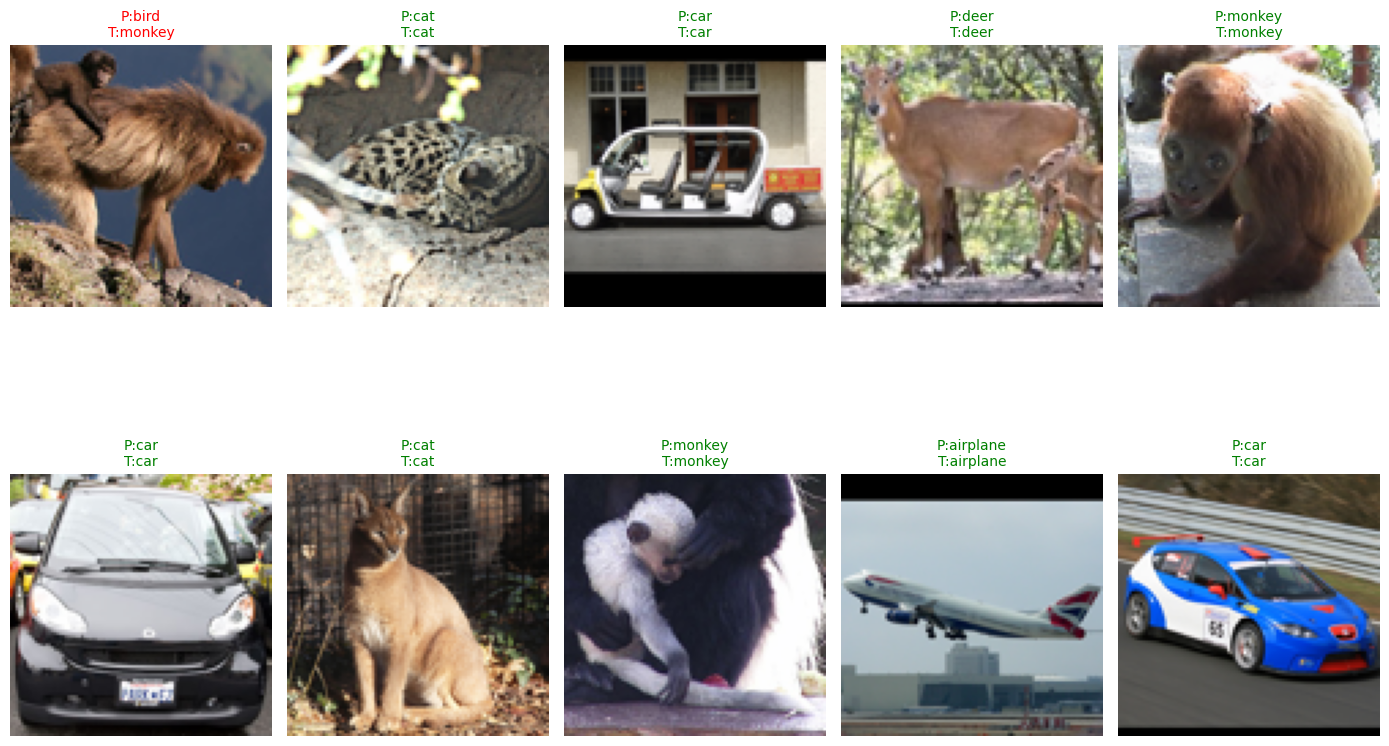

In [ ]:
# LightCNN + Residual Attention on STL10 (96x96 images)
# Colab-ready code

!pip install opencv-python

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random
import time

# -------------------------
# Config
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
TRAIN_SAMPLES = 5000   # small subset for speed (STL10 train = 5000 images total)
VAL_SAMPLES = 800
SEED = 42
NUM_CLASSES = 10

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# STL10 dataset (96x96, high quality)
# -------------------------
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066),
                         (0.2603, 0.2566, 0.2713))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066),
                         (0.2603, 0.2566, 0.2713))
])

train_full = datasets.STL10(root='./data', split="train", download=True, transform=transform_train)
test_full  = datasets.STL10(root='./data', split="test", download=True, transform=transform_test)

# Take subset for quick training
train_idx = list(range(len(train_full)))
random.shuffle(train_idx)
train_idx = train_idx[:TRAIN_SAMPLES]

val_idx = list(range(len(test_full)))
random.shuffle(val_idx)
val_idx = val_idx[:VAL_SAMPLES]

train_ds = Subset(train_full, train_idx)
val_ds = Subset(test_full, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = train_full.classes

# -------------------------
# Model components
# -------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, out_planes, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, 1, stride, bias=False),
                nn.BatchNorm2d(out_planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avgpool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        cat = torch.cat([max_pool, avg_pool], dim=1)
        attn = self.sigmoid(self.conv(cat))
        return x * attn

class ResidualAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()
        self.refine = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        out = self.ca(x)
        out = self.sa(out)
        out = self.refine(out)
        return x + out

class LightCNN_Att(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualAttention(32))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, stride=2), ResidualAttention(64))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualAttention(128))
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x).view(x.size(0), -1)
        return self.fc(x)

# -------------------------
# Training utilities
# -------------------------
def evaluate(model, loader, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

model = LightCNN_Att(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Device: {DEVICE}, Params: {count_params(model):,}")

# -------------------------
# Training loop
# -------------------------
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)
    print(f"Epoch {epoch}/{EPOCHS} | Train loss {train_loss:.4f}, acc {train_acc:.4f} "
          f"| Val loss {val_loss:.4f}, acc {val_acc:.4f}")


# -------------------------
# Visualization of predictions
# -------------------------
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.4467, 0.4398, 0.4066])
    std = np.array([0.2603, 0.2566, 0.2713])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

model.eval()
sample_images, sample_labels = next(iter(val_loader))
sample_images, sample_labels = sample_images.to(DEVICE), sample_labels.to(DEVICE)
with torch.no_grad():
    outputs = model(sample_images[:12])
    preds = outputs.argmax(dim=1)

# Plot first 8 images with preds vs labels
fig, axes = plt.subplots(2, 5, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    img = imshow(sample_images[i])
    ax.imshow(img)
    pred_label = classes[preds[i]]
    true_label = classes[sample_labels[i]]
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"P:{pred_label}\nT:{true_label}", color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
class TraditionalCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 96 -> 48

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 48 -> 24

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 24 -> 12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc = evaluate(model, val_loader, device)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"[{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time
    return model, history, total_time

In [ ]:
# LightCNN (keep as is)
light_model = LightCNN_Att(num_classes=NUM_CLASSES)
light_model, light_hist, light_time = train_model(
    light_model, train_loader, val_loader, EPOCHS, LR, DEVICE
)

# Traditional CNN (train fewer epochs)
baseline_model = TraditionalCNN(num_classes=NUM_CLASSES)
baseline_model, base_hist, base_time = train_model(
    baseline_model, train_loader, val_loader, 10, LR, DEVICE
)

[1/20] Train Acc: 0.3148 | Val Acc: 0.3538
[2/20] Train Acc: 0.3984 | Val Acc: 0.3588
[3/20] Train Acc: 0.4652 | Val Acc: 0.4350
[4/20] Train Acc: 0.5076 | Val Acc: 0.4825
[5/20] Train Acc: 0.5260 | Val Acc: 0.4587
[6/20] Train Acc: 0.5530 | Val Acc: 0.5025
[7/20] Train Acc: 0.5876 | Val Acc: 0.5250
[8/20] Train Acc: 0.5972 | Val Acc: 0.5975
[9/20] Train Acc: 0.6170 | Val Acc: 0.5487
[10/20] Train Acc: 0.6312 | Val Acc: 0.5038
[11/20] Train Acc: 0.6520 | Val Acc: 0.4537
[12/20] Train Acc: 0.6548 | Val Acc: 0.5687
[13/20] Train Acc: 0.6698 | Val Acc: 0.5300
[14/20] Train Acc: 0.6676 | Val Acc: 0.6050
[15/20] Train Acc: 0.6744 | Val Acc: 0.5650
[16/20] Train Acc: 0.6888 | Val Acc: 0.6488
[17/20] Train Acc: 0.7044 | Val Acc: 0.5463
[18/20] Train Acc: 0.7044 | Val Acc: 0.5725
[19/20] Train Acc: 0.7158 | Val Acc: 0.5563
[20/20] Train Acc: 0.7224 | Val Acc: 0.6512
[1/10] Train Acc: 0.3056 | Val Acc: 0.4250
[2/10] Train Acc: 0.4598 | Val Acc: 0.5038
[3/10] Train Acc: 0.5350 | Val Acc: 0.5525


In [ ]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("\n===== FINAL COMPARISON =====")
print(f"LightCNN Params: {count_params(light_model):,}")
print(f"Traditional CNN Params: {count_params(baseline_model):,}")

print(f"\nLightCNN Final Val Acc: {light_hist['val_acc'][-1]:.4f}")
print(f"Traditional CNN Final Val Acc: {base_hist['val_acc'][-1]:.4f}")

print(f"\nLightCNN Training Time: {light_time:.2f}s")
print(f"Traditional CNN Training Time: {base_time:.2f}s")


===== FINAL COMPARISON =====
LightCNN Params: 336,272
Traditional CNN Params: 4,814,666

LightCNN Final Val Acc: 0.6512
Traditional CNN Final Val Acc: 0.6312

LightCNN Training Time: 227.54s
Traditional CNN Training Time: 43.30s


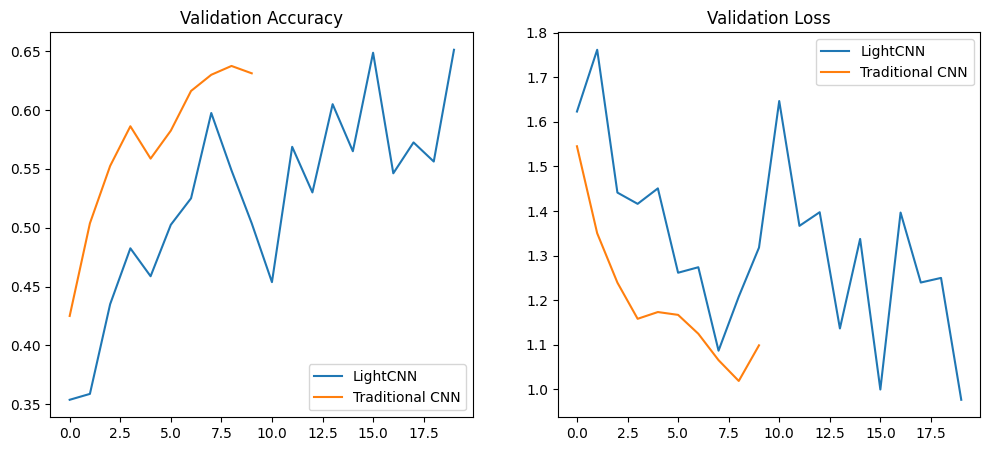

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(light_hist["val_acc"], label="LightCNN")
plt.plot(base_hist["val_acc"], label="Traditional CNN")
plt.title("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(light_hist["val_loss"], label="LightCNN")
plt.plot(base_hist["val_loss"], label="Traditional CNN")
plt.title("Validation Loss")
plt.legend()

plt.show()

<Figure size 800x800 with 0 Axes>

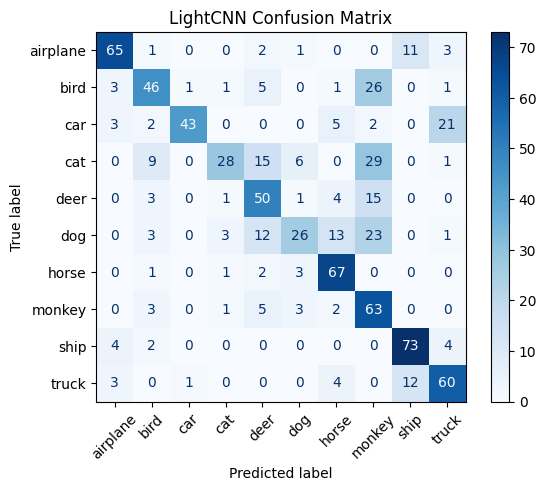

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# LightCNN confusion matrix
preds, labels = get_predictions(light_model, val_loader)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("LightCNN Confusion Matrix")
plt.show()

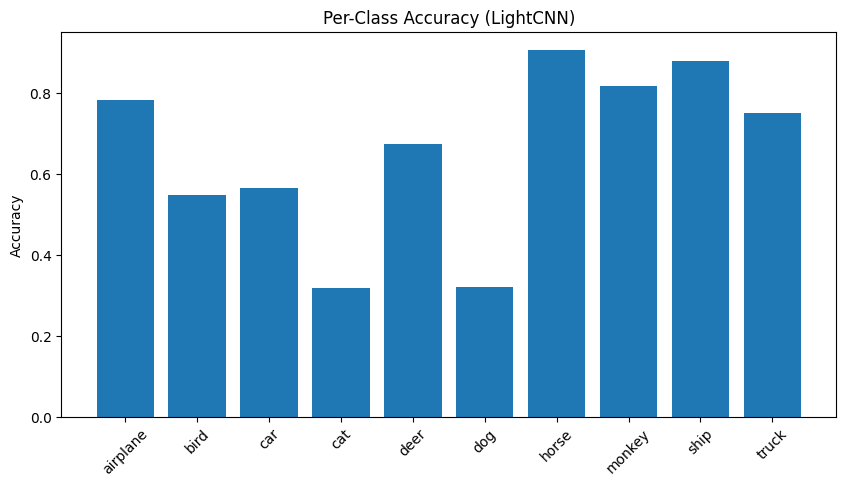

In [ ]:
def per_class_accuracy(cm):
    return cm.diagonal() / cm.sum(axis=1)

acc_per_class = per_class_accuracy(cm)

plt.figure(figsize=(10,5))
plt.bar(classes, acc_per_class)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy (LightCNN)")
plt.show()

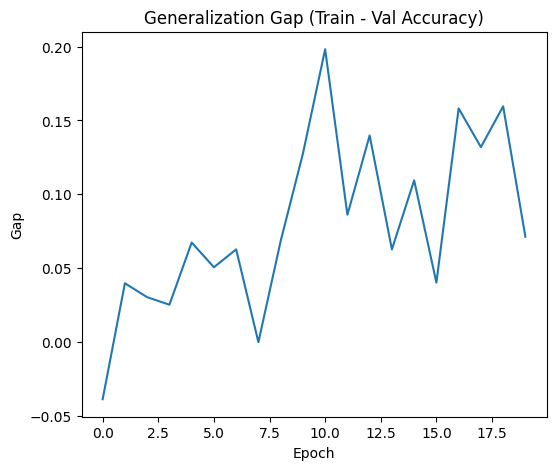

In [ ]:
plt.figure(figsize=(6,5))
gap = np.array(light_hist["train_acc"]) - np.array(light_hist["val_acc"])
plt.plot(gap)
plt.title("Generalization Gap (Train - Val Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.show()

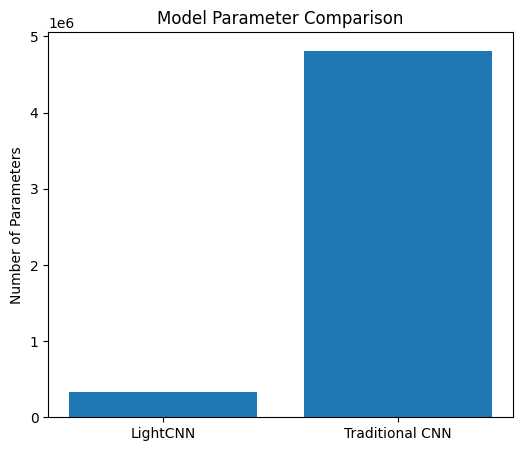

In [ ]:
light_params = count_params(light_model)
base_params = count_params(baseline_model)

plt.figure(figsize=(6,5))
plt.bar(["LightCNN", "Traditional CNN"], [light_params, base_params])
plt.title("Model Parameter Comparison")
plt.ylabel("Number of Parameters")
plt.show()

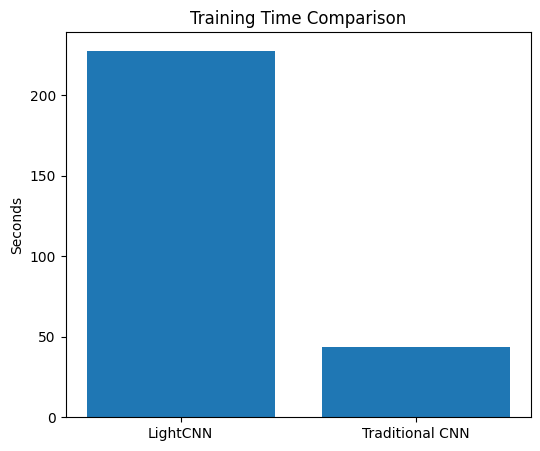

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(["LightCNN", "Traditional CNN"], [light_time, base_time])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

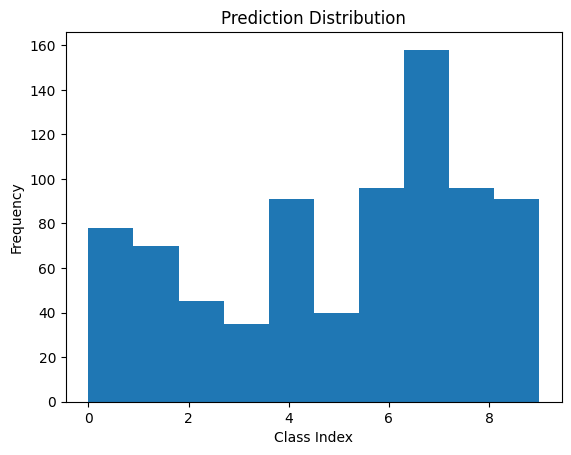

In [ ]:
plt.hist(preds, bins=len(classes))
plt.title("Prediction Distribution")
plt.xlabel("Class Index")
plt.ylabel("Frequency")
plt.show()

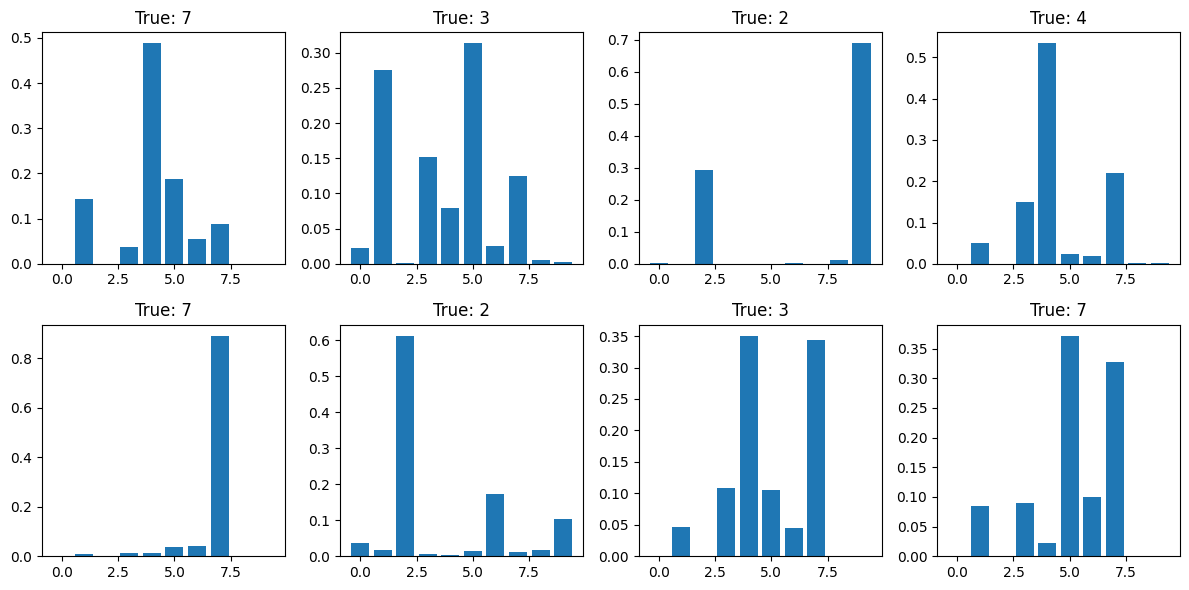

In [ ]:
import torch.nn.functional as F

model = light_model
model.eval()

images, labels = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images[:8])
    probs = F.softmax(outputs, dim=1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.bar(range(NUM_CLASSES), probs[i].cpu().numpy())
    plt.title(f"True: {labels[i]}")
plt.tight_layout()
plt.show()

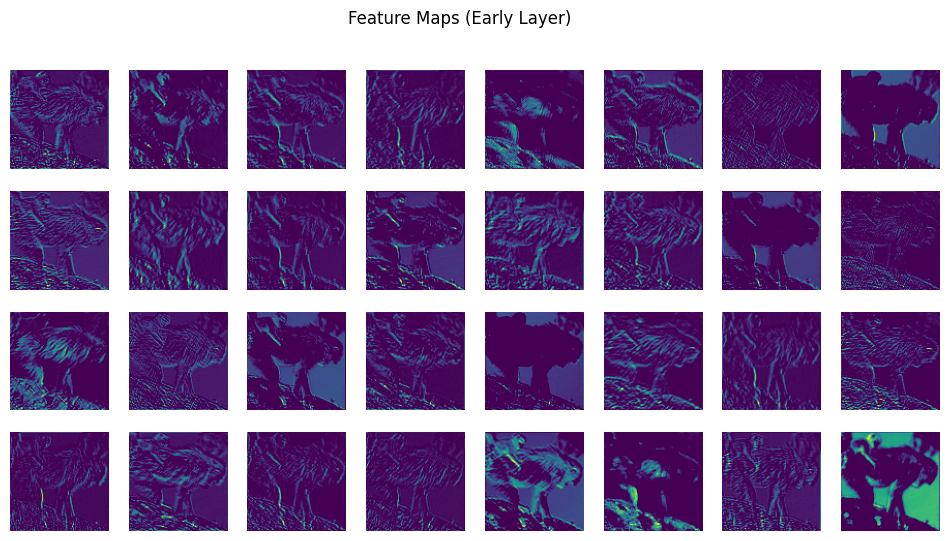

In [ ]:
def visualize_feature_maps(model, image):
    model.eval()
    x = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        x = model.stem(x)
        features = x[0].cpu()

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    for i, ax in enumerate(axes.flat):
        if i < features.shape[0]:
            ax.imshow(features[i], cmap='viridis')
        ax.axis("off")
    plt.suptitle("Feature Maps (Early Layer)")
    plt.show()

# run
visualize_feature_maps(light_model, sample_images[0].cpu())

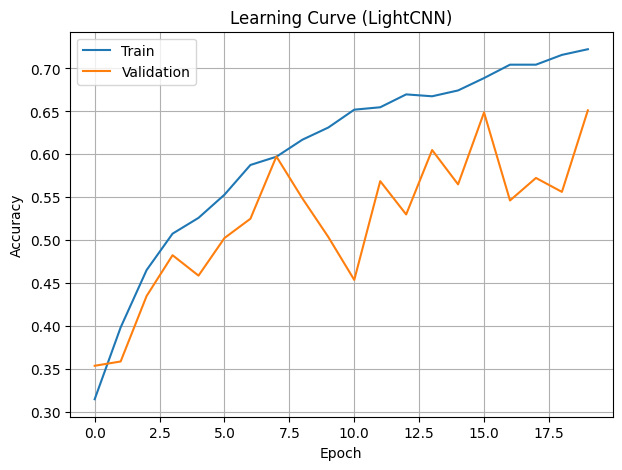

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(light_hist["train_acc"], label="Train")
plt.plot(light_hist["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve (LightCNN)")
plt.legend()
plt.grid()
plt.show()